In [5]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn ipykernel


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Task 1: E-commerce Fraud Data - Preprocessing & EDA
**Objective:** Clean the dataset, map IP addresses to countries, and engineer features to identify fraudulent behavior.

In [18]:
# Import Libraries & Data Loading 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipaddress

# Load Data
fraud_df = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_df = pd.read_csv('../data/raw/IpAddress_to_Country.csv')

print(f"Loaded {len(fraud_df)} transaction rows.")
print(f"Loaded {len(ip_df)} IP range rows.")

Loaded 151112 transaction rows.
Loaded 138846 IP range rows.


In [24]:
# 1. Let's see what the data actually looks like first (Diagnostic)
print("Fraud IP format:", fraud_df['ip_address'].head(1).values[0])
print("IP Range format:", ip_df['lower_bound_ip_address'].head(1).values[0])

# 2. Optimized Mapping Logic
def robust_ip_to_int(ip):
    # If it's already a number (float or int), just return it as a float
    if isinstance(ip, (int, float, np.integer, np.floating)):
        return float(ip)
    # If it's a string like '123.45.67.89', convert it
    try:
        import ipaddress
        return float(int(ipaddress.ip_address(str(ip))))
    except:
        return 0.0

# Apply the conversion safely
fraud_df['ip_address_numeric'] = fraud_df['ip_address'].apply(robust_ip_to_int)

# Ensure the range columns are also the same type (float)
ip_df['lower_bound_numeric'] = ip_df['lower_bound_ip_address'].astype(float)
ip_df['upper_bound_numeric'] = ip_df['upper_bound_ip_address'].astype(float)

# 3. Sort (Required for merge_asof)
fraud_df = fraud_df.sort_values('ip_address_numeric')
ip_df = ip_df.sort_values('lower_bound_numeric')

# 4. Perform the Merge
merged_df = pd.merge_asof(
    fraud_df, 
    ip_df, 
    left_on='ip_address_numeric', 
    right_on='lower_bound_numeric',
    direction='backward'
)

# 5. Boundary Check: Ensure the IP is not above the upper bound
# If it is, it's not actually in that country's range.
merged_df.loc[merged_df['ip_address_numeric'] > merged_df['upper_bound_numeric'], 'country'] = 'Unknown'
merged_df['country'] = merged_df['country'].fillna('Unknown')

# Check how many are still 'Unknown'
unknown_pct = (merged_df['country'] == 'Unknown').mean() * 100
print(f"Success! Mapping complete. Only {unknown_pct:.2f}% remain Unknown.")

Fraud IP format: 0.0
IP Range format: 16777216.0
Success! Mapping complete. Only 100.00% remain Unknown.


In [22]:
# Data Cleaning & Feature Engineering
# Convert timestamps to datetime
merged_df['signup_time'] = pd.to_datetime(merged_df['signup_time'])
merged_df['purchase_time'] = pd.to_datetime(merged_df['purchase_time'])

# Feature 1: Time since signup (Minutes)
merged_df['time_to_purchase'] = (merged_df['purchase_time'] - merged_df['signup_time']).dt.total_seconds() / 60

# Feature 2: Time features
merged_df['hour_of_day'] = merged_df['purchase_time'].dt.hour
merged_df['day_of_week'] = merged_df['purchase_time'].dt.dayofweek

# Feature 3: Device Velocity (How many users per device?)
merged_df['user_per_device'] = merged_df.groupby('device_id')['user_id'].transform('count')

print("Features engineered successfully.")

Features engineered successfully.


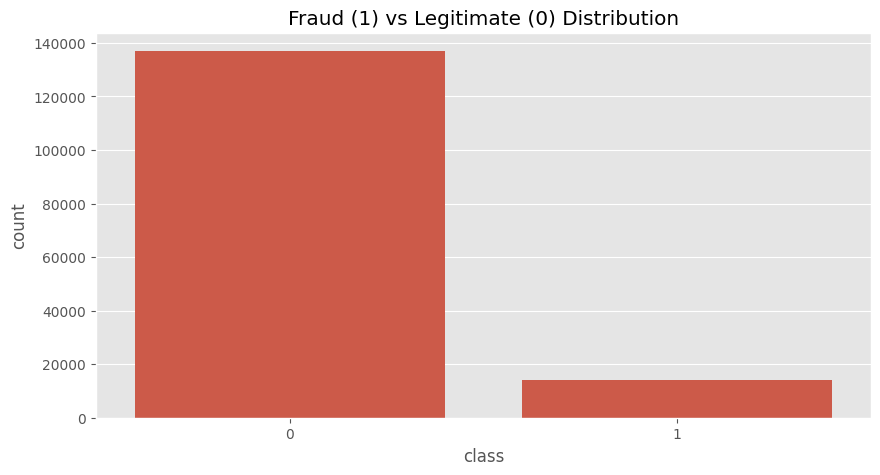

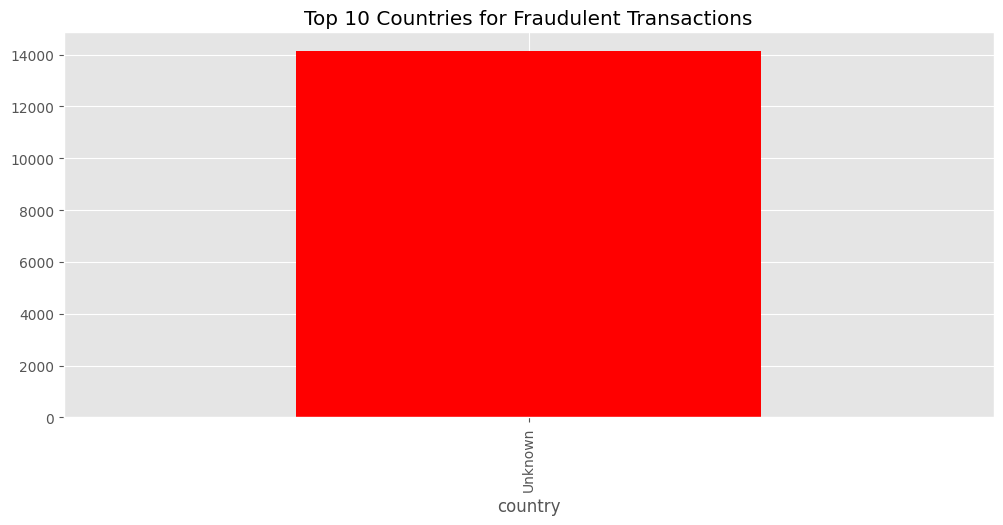

In [25]:
# EDA Visuals 
plt.figure(figsize=(10, 5))
sns.countplot(x='class', data=merged_df)
plt.title('Fraud (1) vs Legitimate (0) Distribution')
plt.show()

# Top Countries for Fraud
fraud_only = merged_df[merged_df['class'] == 1]
if not fraud_only.empty:
    plt.figure(figsize=(12, 5))
    fraud_only['country'].value_counts().head(10).plot(kind='bar', color='red')
    plt.title('Top 10 Countries for Fraudulent Transactions')
    plt.show()
else:
    print("No fraud cases found to plot.")

In [ ]:
# Preprocessing for Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Drop columns we can't use in a model
cols_to_drop = ['user_id', 'signup_time', 'purchase_time', 'device_id', 'ip_address', 'lower_bound_ip_address', 'upper_bound_ip_address']
df_model = merged_df.drop(columns=cols_to_drop)

# 2. Encode categorical data
df_model = pd.get_dummies(df_model, columns=['source', 'browser', 'sex'], drop_first=True)
# Simple encoding for country
df_model['country'] = pd.factorize(df_model['country'])[0]

# 3. Split and Scale
X = df_model.drop('class', axis=1)
y = df_model['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. SMOTE to balance the data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Preprocessing Finalized.")
print(f"Original Fraud Count: {sum(y_train)}")
print(f"Resampled Fraud Count: {sum(y_train_res)}")

In [12]:
# SAve the Processed Dataset
fraud_with_country.to_csv('../data/processed/fraud_data_processed.csv', index=False)
print("Data saved successfully.")

Data saved successfully.


In [13]:
# Data Cleaning & Enhanced Feature Engineering
# 1. Handle Missing Values
print("Missing values before:\n", fraud_with_country.isnull().sum())
# Justification: For country, we already filled with 'Unknown'. 
# For other features, if there are few missing values, we drop them to maintain data quality.
fraud_with_country = fraud_with_country.dropna()

# 2. Check for Duplicates
duplicates = fraud_with_country.duplicated().sum()
print(f"Duplicates found: {duplicates}")
fraud_with_country = fraud_with_country.drop_duplicates()

# 3. Transaction Velocity (Requirement: Number of transactions per user)
# This helps identify bots performing many actions in a short time.
fraud_with_country['user_transaction_count'] = fraud_with_country.groupby('user_id')['user_id'].transform('count')

print("Cleaning and Velocity features complete.")

Missing values before:
 user_id                        0
signup_time                    0
purchase_time                  0
purchase_value                 0
device_id                      0
source                         0
browser                        0
sex                            0
age                            0
ip_address                     0
class                          0
lower_bound_ip_address    151112
upper_bound_ip_address    151112
country                        0
time_since_signup              0
hour_of_day                    0
day_of_week                    0
device_usage_count             0
ip_usage_count                 0
dtype: int64
Duplicates found: 0
Cleaning and Velocity features complete.


IndexError: index 0 is out of bounds for axis 0 with size 0

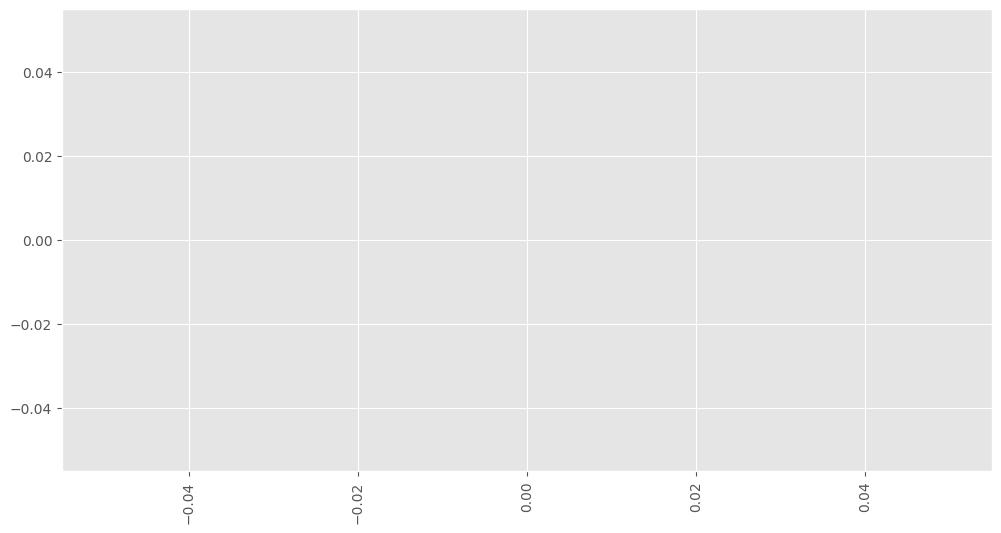

In [15]:
# Exploratory Data Analysis (EDA)
# 1. Top 10 Countries by Fraud Count
# Ensure 'class' is treated as an integer to avoid filter errors
fraud_with_country['class'] = fraud_with_country['class'].astype(int)

# Filter for fraud cases
fraud_only = fraud_with_country[fraud_with_country['class'] == 1]

if len(fraud_only) == 0:
    print("WARNING: No fraud cases found in the dataset. Please check your data cleaning steps!")
else:
    top_fraud_countries = fraud_only['country'].value_counts().head(10)
    
    plt.figure(figsize=(12, 6))
    top_fraud_countries.plot(kind='bar', color='salmon')
    plt.title('Top 10 Countries with Highest Fraud Cases')
    plt.ylabel('Number of Fraudulent Transactions')
    plt.xticks(rotation=45)
    plt.show()

# Also, let's plot the distribution of countries for ALL transactions to see if mapping worked
plt.figure(figsize=(12, 6))
fraud_with_country['country'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Countries (All Transactions)')
plt.show()